# 이미지 불러오기
PIL 라이브러리 이용

In [7]:
from PIL import Image

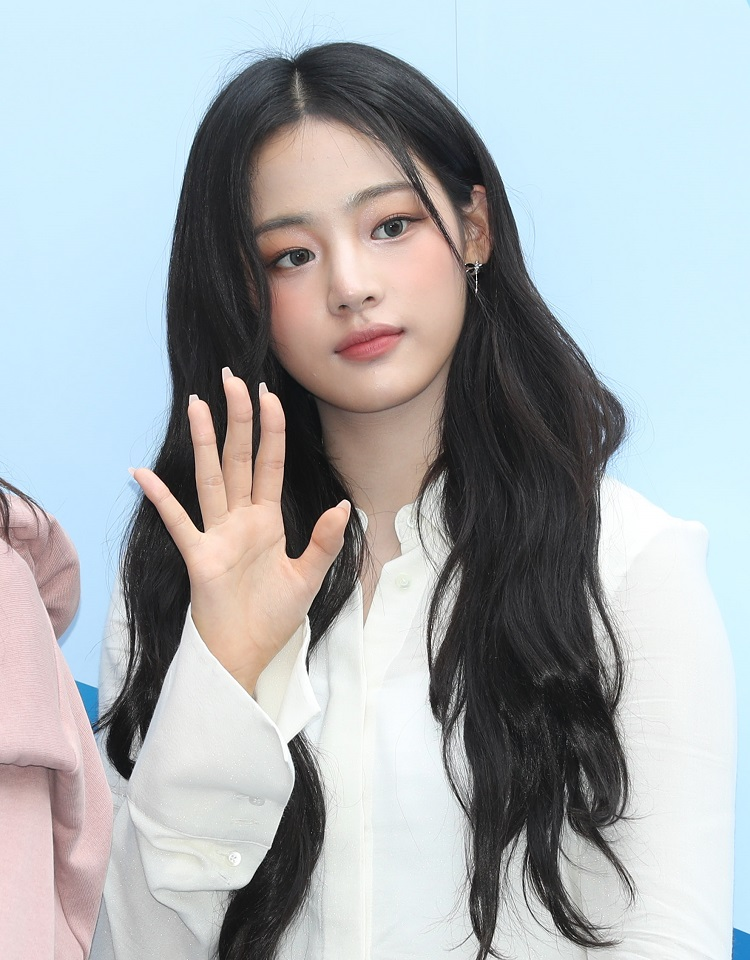

In [8]:
img = Image.open('minji.png')
img

In [9]:
# PIL 타입
type(img)

PIL.PngImagePlugin.PngImageFile

array([[[212, 241, 255],
        [212, 241, 255],
        [212, 241, 255],
        ...,
        [175, 224, 241],
        [172, 227, 248],
        [171, 229, 251]],

       [[212, 241, 255],
        [212, 241, 255],
        [212, 241, 255],
        ...,
        [180, 227, 245],
        [170, 225, 246],
        [170, 228, 250]],

       [[212, 241, 255],
        [212, 241, 255],
        [212, 241, 255],
        ...,
        [189, 235, 251],
        [172, 224, 245],
        [171, 228, 248]],

       ...,

       [[241, 216, 219],
        [239, 214, 217],
        [236, 214, 216],
        ...,
        [ 34, 133, 201],
        [ 35, 132, 201],
        [ 35, 132, 201]],

       [[242, 217, 220],
        [239, 214, 217],
        [236, 214, 216],
        ...,
        [ 34, 132, 203],
        [ 35, 132, 201],
        [ 37, 131, 201]],

       [[241, 216, 219],
        [238, 213, 216],
        [235, 213, 215],
        ...,
        [ 34, 132, 203],
        [ 36, 130, 200],
        [ 36, 130, 200]]], dtype=uint8)
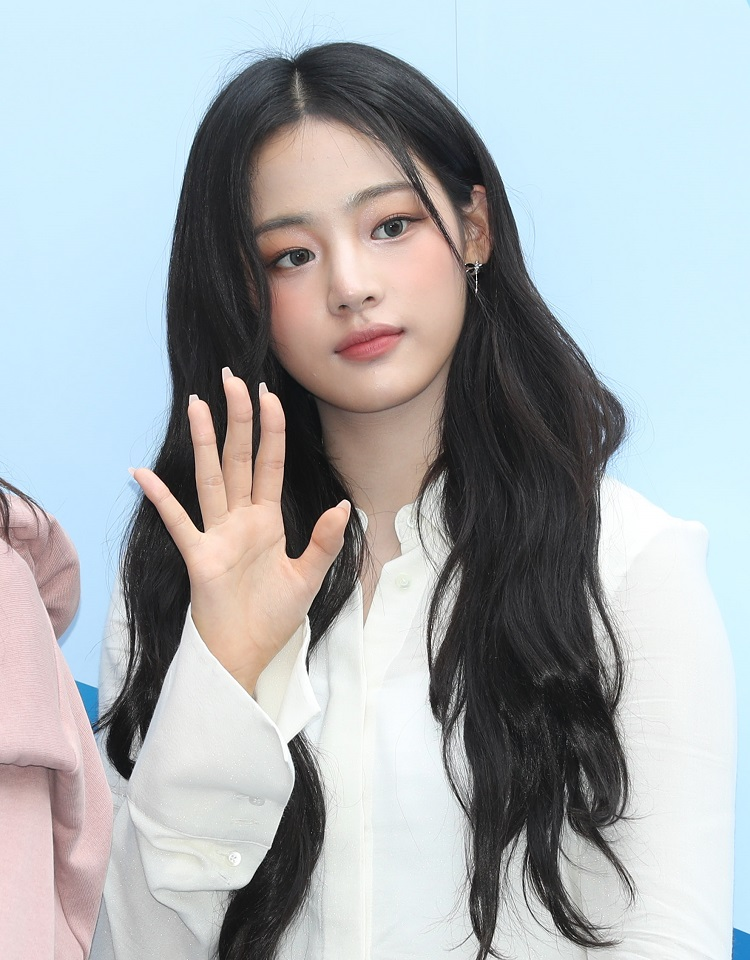

In [10]:
# numpy로 변환
import numpy as np

img_array = np.array(img)
img_array

In [11]:
# (width, height, channel)
img_array.shape

(960, 750, 3)

# 데이터 처리

1. 데이터 준비
2. train, test 데이터 폴더를 따로 만든다
3. 전처리를 위한 transformer를 만든다
4. 데이터 로더로 파이토치가 이미지 불러올 수 있는 형태로 만든다(데이터 로더가 배치 단위로 쪼개주고, 전처리도 바로 적용해줘서)
5. 모델 결정, 만들기(Sequential, Module)

## 필요 라이브러리 임포트

In [12]:
import torch
import numpy as np
import  torch.nn as nn # 신경망 모델 정의
import torch.nn.functional as F # 신경망에서 사용하는 함수
from torch.optim import Adam # 최적화 함수
import torchvision.transforms as transforms # 이미지 전처리 및 변환
from torchvision.datasets import MNIST # 데이터셋
from torch.utils.data import DataLoader # 데이터로더
import matplotlib.pyplot as plt # 시각화

In [13]:
# gpu 확인
torch.cuda.is_available()

False

## 데이터 전처리(torchvision.transforms 사용)

In [14]:
data_transform = transforms.Compose([
    transforms.ToTensor(), # 텐서로 바꿔라
    transforms.Resize(32), # 32x32 사이즈로 변환
    transforms.Normalize((0.5), (1.0)) # 평균이 0.5고, 표준편차가 1.0인 이미지로 변환
])

## 데이터 다운

In [15]:
# train. test 이미지 데이터셋 필요
# torch vision 사용하면 불러오면서 이미지 분리도 함
train_data = MNIST('./', train=True, transform=data_transform, download=True) # 불러올 경로, 사용할 transform, 다운로드 할 건지
test_data = MNIST('./', train=False, transform=data_transform, download=True) # 불러올 경로, 사용할 transform, 다운로드 할 건지

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.34MB/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



## 데이터 확인

In [16]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=32, interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=0.5, std=1.0)
           )

In [17]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=32, interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=0.5, std=1.0)
           )

In [18]:
# 데이터 확인
train_data.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [19]:
train_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [20]:
train_data.data.shape, train_data.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

## 차원 확인

data shape  
[batch, channel, width, height]

In [21]:
# batch, width, height
# 채널 없음(흑백이라)
train_data.data.shape

torch.Size([60000, 28, 28])

## 차원 추가해서 x_train 만들기

In [22]:
# 채널 차원 추가: unsqueeze(dim=)
train_data.data.unsqueeze(dim=0).shape

torch.Size([1, 60000, 28, 28])

In [23]:
# batch, channel, w, h
train_data.data.unsqueeze(dim=1).shape

torch.Size([60000, 1, 28, 28])

In [24]:
train_data.data.unsqueeze(dim=2).shape

torch.Size([60000, 28, 1, 28])

In [25]:
train_data.data.unsqueeze(dim=3).shape

torch.Size([60000, 28, 28, 1])

In [26]:
x_train = train_data.data.unsqueeze(dim=1)
x_train.shape

torch.Size([60000, 1, 28, 28])

In [27]:
# 60000개 중 첫 번째 것
# (channel, w, h)
x_train.data[0].shape

torch.Size([1, 28, 28])

In [28]:
x_train.data[0]

tensor([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
           18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,

## tensor 배열 numpy 배열로 바꿔 확인

In [29]:
import matplotlib.pyplot as plt

In [30]:
def imgshow(tensor_array, cmap=None):
  # tensor -> numpy
  numpy_array = tensor_array.numpy()
  # 차원 변환 (channel, w, h) -> (w, h, channel)
  num_img = numpy_array.transpose(1,2,0) # (0, 1, 2) -> (1, 2, 0)
  plt.axis('off') # 눈금 제거
  plt.imshow(num_img, cmap=cmap)

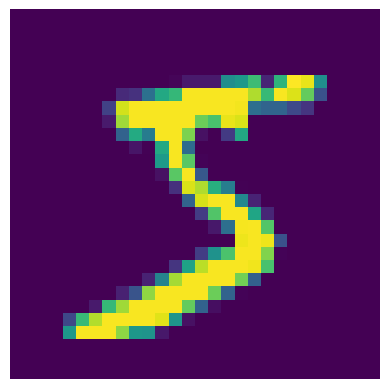

In [31]:
imgshow(x_train.data[0])

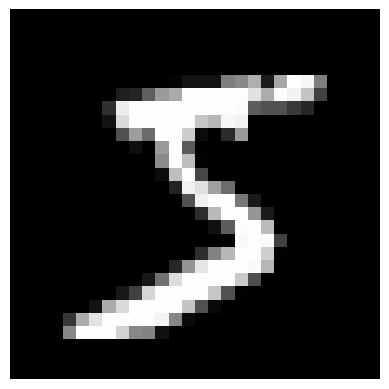

In [32]:
imgshow(x_train.data[0], cmap='gray')

In [33]:
# 답 확인
train_data.targets[0].item()

5

## 데이터 배치 단위로 불러오기(DataLoader)

In [34]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=32, interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=0.5, std=1.0)
           )

In [35]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=32, interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=0.5, std=1.0)
           )

In [36]:
# 데이터  불러오기
# 한 번에 다 학습시키지 못하니까 배치 단위로 쪼개서 한다: DataLoader
from torch.utils.data import DataLoader

In [37]:
# 32개 이미지씩 한 번에
# 배치를 많이 넣으면 한꺼번에 학습 많이 돼서 속도는 빠르지만 메모리는 많이 먹음 -> 본인 메모리카드가 버틸 수 있을 때까지
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

## DataLoader 보는 법

In [38]:
train_loader.batch_size

32

In [39]:
# 배치 단위로 하나씩 불러오기
# 첫 번째 32개 가져오기 : [데이터, 타깃] 이렇게 되어있음
next(iter(train_loader))

[tensor([[[[-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           ...,
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000]]],
 
 
         [[[-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           ...,
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
           [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000]]],
 
 
         [[[-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
       

In [40]:
data, target = next(iter(train_loader))

In [41]:
data.shape

torch.Size([32, 1, 32, 32])

In [42]:
target.shape

torch.Size([32])

In [43]:
# 전처리 전, 전처리 후
x_train.data[0].shape, data[0].shape

(torch.Size([1, 28, 28]), torch.Size([1, 32, 32]))

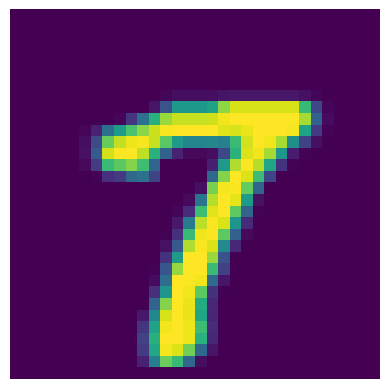

In [44]:
imgshow(data[0])

In [45]:
target[0]

tensor(7)